# Treinamento KNN em Dois Datasets
Este notebook testa o algoritmo KNN em conjuntos de dados processados.

- Tabela A: `coffee_classificado.csv` contém apenas variáveis de produção e colunas categóricas, sem notas sensoriais.
- Tabela B: `coffee_classificado_sensoriais.csv` inclui as mesmas colunas de produção mais as variáveis sensoriais (`Aroma`, `Flavor`, `Aftertaste`, `Acidity`, `Body`, `Balance`, `Uniformity`, `Clean_Cup`, `Sweetness`).

O notebook compara o desempenho de KNN usando ambas as tabelas para mostrar o impacto das notas sensoriais.

# KNN sem tabela com notas sensoriais

In [2]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score

# 1. Carregamento
df = pd.read_csv('../data/processed/coffee_classificado.csv')

colunas_numericas = ['Moisture', 'Category_One_Defects', 'Category_Two_Defects', 'Quakers', 'Altitude']
colunas_categoricas = ['Variety', 'Processing_Method', 'Country_of_Origin', 'Color']

X = df[colunas_numericas + colunas_categoricas]
y = df['Classe']

# 2. Encoding
X_encoded = pd.get_dummies(X, columns=colunas_categoricas, drop_first=True)
print("Shape após encoding:", X_encoded.shape)

# 3. Split treino/teste
X_train, X_test, y_train, y_test = train_test_split(
    X_encoded, y, test_size=0.2, stratify=y, random_state=42
)

# 4. Normalização (só nas colunas numéricas originais)
scaler = StandardScaler()
X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()
X_train_scaled[colunas_numericas] = scaler.fit_transform(X_train[colunas_numericas])
X_test_scaled[colunas_numericas] = scaler.transform(X_test[colunas_numericas])

# 5. Testando K = 3, 5, 7 com Euclidiana e Manhattan
resultados = []
for k in [3, 5, 7]:
    for metrica in ['euclidean', 'manhattan']:
        knn = KNeighborsClassifier(n_neighbors=k, metric=metrica)
        knn.fit(X_train_scaled, y_train)
        y_pred = knn.predict(X_test_scaled)
        resultados.append({
            'K': k,
            'Metrica': metrica,
            'Acuracia': round(accuracy_score(y_test, y_pred), 4),
            'F1_Macro': round(float(f1_score(y_test, y_pred, average='macro')), 4)
        })

resultados_df = pd.DataFrame(resultados).sort_values('F1_Macro', ascending=False)
print("\n=== Comparação de K e métricas de distância ===")
print(resultados_df.to_string(index=False))

# 6. Treinar o melhor modelo encontrado e avaliar em detalhe
melhor = resultados_df.iloc[0]
print(f"\n=== Melhor combinação: K={int(melhor['K'])}, {melhor['Metrica']} ===")

knn_final = KNeighborsClassifier(n_neighbors=int(melhor['K']), metric=melhor['Metrica'])
knn_final.fit(X_train_scaled, y_train)
y_pred_final = knn_final.predict(X_test_scaled)

print("Acurácia:", accuracy_score(y_test, y_pred_final))
print(classification_report(y_test, y_pred_final))
print("Matriz de confusão:")
print(confusion_matrix(y_test, y_pred_final, labels=['Tradicional','Superior','Gourmet']))

Shape após encoding: (1506, 57)

=== Comparação de K e métricas de distância ===
 K   Metrica  Acuracia  F1_Macro
 7 euclidean    0.5066    0.4995
 7 manhattan    0.4967    0.4929
 5 euclidean    0.4834    0.4796
 5 manhattan    0.4570    0.4613
 3 euclidean    0.4305    0.4334
 3 manhattan    0.4172    0.4222

=== Melhor combinação: K=7, euclidean ===
Acurácia: 0.5066225165562914
              precision    recall  f1-score   support

     Gourmet       0.55      0.41      0.47        70
    Superior       0.49      0.57      0.53       127
 Tradicional       0.52      0.49      0.50       105

    accuracy                           0.51       302
   macro avg       0.52      0.49      0.50       302
weighted avg       0.51      0.51      0.50       302

Matriz de confusão:
[[51 48  6]
 [36 73 18]
 [12 29 29]]


In [3]:
# ======================================================
# Guardar resultados desta seção (sem notas sensoriais)
# para usar depois no gráfico comparativo final
# ======================================================
resultados_knn_sem = resultados_df.copy()
y_test_knn_sem = y_test.copy()
y_pred_knn_sem = y_pred_final.copy()


# KNN com tabela com notas sensoriais

In [4]:
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    f1_score
)

# ======================================================
# 1. Carregamento
# ======================================================

df = pd.read_csv("../data/processed/coffee_classificado_sensoriais.csv")

# ======================================================
# 2. Features
# ======================================================

colunas_numericas = [
    "Moisture",
    "Category_One_Defects",
    "Category_Two_Defects",
    "Quakers",
    "Altitude",
    "Aroma",
    "Flavor",
    "Aftertaste",
    "Acidity",
    "Body",
    "Balance",
    "Uniformity",
    "Clean_Cup",
    "Sweetness"
]

colunas_categoricas = [
    "Variety",
    "Processing_Method",
    "Country_of_Origin",
    "Color"
]

X = df[colunas_numericas + colunas_categoricas]
y = df["Classe"]

# ======================================================
# 3. One-Hot Encoding
# ======================================================

X_encoded = pd.get_dummies(
    X,
    columns=colunas_categoricas,
    drop_first=True
)

print("Shape após encoding:", X_encoded.shape)

# ======================================================
# 4. Split
# ======================================================

X_train, X_test, y_train, y_test = train_test_split(
    X_encoded,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

# ======================================================
# 5. Padronização
# ======================================================

scaler = StandardScaler()

X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

X_train_scaled[colunas_numericas] = scaler.fit_transform(
    X_train[colunas_numericas]
)

X_test_scaled[colunas_numericas] = scaler.transform(
    X_test[colunas_numericas]
)

# ======================================================
# 6. Teste dos modelos
# ======================================================

resultados = []

for k in [3, 5, 7]:
    for metrica in ["euclidean", "manhattan"]:

        modelo = KNeighborsClassifier(
            n_neighbors=k,
            metric=metrica
        )

        modelo.fit(X_train_scaled, y_train)

        y_pred = modelo.predict(X_test_scaled)

        resultados.append({
            "K": k,
            "Métrica": metrica,
            "Accuracy": accuracy_score(y_test, y_pred),
            "F1 Macro": f1_score(
                y_test,
                y_pred,
                average="macro"
            )
        })

resultados = (
    pd.DataFrame(resultados)
      .sort_values("F1 Macro", ascending=False)
)

print(resultados)

# ======================================================
# 7. Melhor modelo
# ======================================================

melhor = resultados.iloc[0]

print("\nMelhor configuração:")
print(melhor)

modelo_final = KNeighborsClassifier(
    n_neighbors=int(melhor["K"]),
    metric=melhor["Métrica"]
)

modelo_final.fit(X_train_scaled, y_train)

y_pred = modelo_final.predict(X_test_scaled)

print("\nAccuracy")
print(accuracy_score(y_test, y_pred))

print("\nClassification Report")
print(classification_report(y_test, y_pred))

print("\nMatriz de Confusão")
print(
    confusion_matrix(
        y_test,
        y_pred,
        labels=["Tradicional", "Superior", "Gourmet"]
    )
)

Shape após encoding: (1508, 121)
   K    Métrica  Accuracy  F1 Macro
3  5  manhattan  0.844371  0.839860
2  5  euclidean  0.837748  0.834467
4  7  euclidean  0.824503  0.817460
1  3  manhattan  0.817881  0.817270
5  7  manhattan  0.814570  0.806986
0  3  euclidean  0.811258  0.805861

Melhor configuração:
K                   5
Métrica     manhattan
Accuracy     0.844371
F1 Macro      0.83986
Name: 3, dtype: object

Accuracy
0.8443708609271523

Classification Report
              precision    recall  f1-score   support

     Gourmet       0.86      0.79      0.82        70
    Superior       0.75      0.88      0.81       103
 Tradicional       0.94      0.84      0.89       129

    accuracy                           0.84       302
   macro avg       0.85      0.84      0.84       302
weighted avg       0.85      0.84      0.85       302


Matriz de Confusão
[[109  16   4]
 [  7  91   5]
 [  0  15  55]]


In [5]:
# ======================================================
# Guardar resultados desta seção (com notas sensoriais)
# para usar depois no gráfico comparativo final
# ======================================================
resultados_knn_com = resultados.copy()
y_test_knn_com = y_test.copy()
y_pred_knn_com = y_pred.copy()


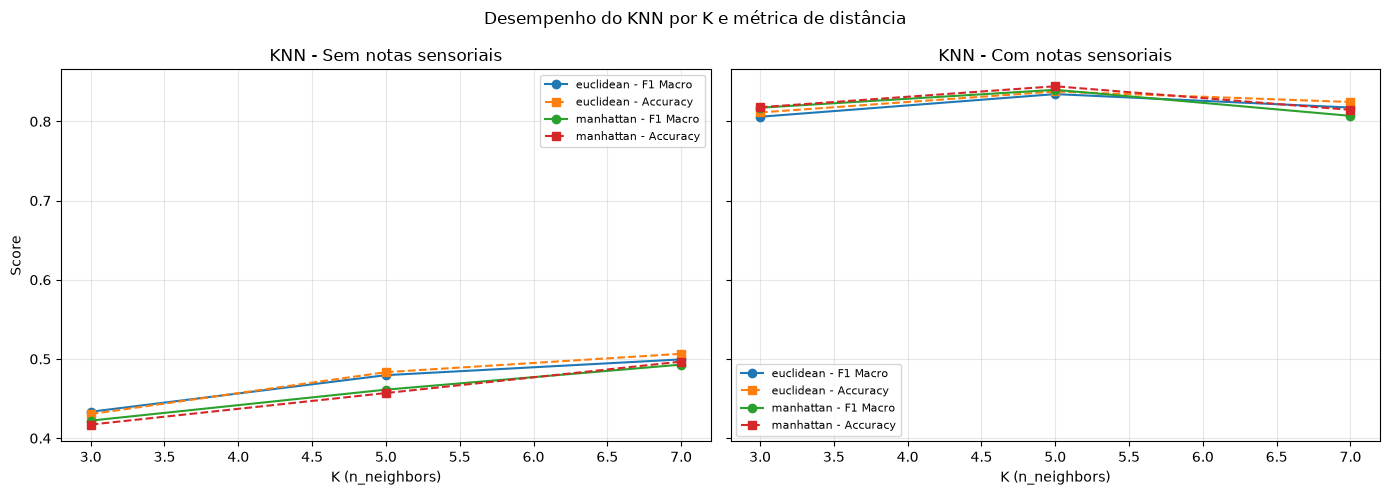

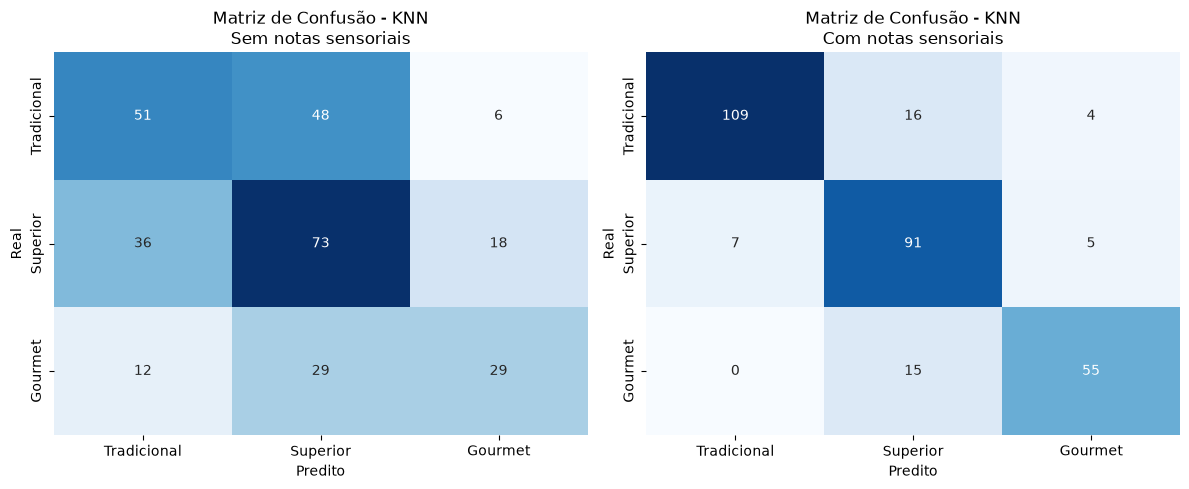

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

labels_classe = ['Tradicional', 'Superior', 'Gourmet']

# ======================================================
# Gráfico 1: desempenho do KNN por K e métrica de distância
# comparando as duas tabelas (sem x com notas sensoriais)
# ======================================================
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

datasets_knn = [
    (resultados_knn_sem, 'Sem notas sensoriais', axes[0]),
    (resultados_knn_com, 'Com notas sensoriais', axes[1]),
]

for resultados_tab, titulo, ax in datasets_knn:
    resultados_tab = resultados_tab.rename(
        columns={'Metrica': 'Métrica', 'Acuracia': 'Accuracy', 'F1_Macro': 'F1 Macro'}
    )
    for metrica, grupo in resultados_tab.groupby('Métrica'):
        grupo = grupo.sort_values('K')
        ax.plot(grupo['K'], grupo['F1 Macro'], marker='o', label=f'{metrica} - F1 Macro')
        ax.plot(grupo['K'], grupo['Accuracy'], marker='s', linestyle='--', label=f'{metrica} - Accuracy')
    ax.set_title(f'KNN - {titulo}')
    ax.set_xlabel('K (n_neighbors)')
    ax.grid(alpha=0.3)
    ax.legend(fontsize=8)

axes[0].set_ylabel('Score')
plt.suptitle('Desempenho do KNN por K e métrica de distância')
plt.tight_layout()
plt.savefig('../images/grafico_knn.png', dpi=150)
plt.show()

# ======================================================
# Gráfico 2: matrizes de confusão dos melhores modelos
# (sem x com notas sensoriais)
# ======================================================
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

cm_sem = confusion_matrix(y_test_knn_sem, y_pred_knn_sem, labels=labels_classe)
cm_com = confusion_matrix(y_test_knn_com, y_pred_knn_com, labels=labels_classe)

for cm, titulo, ax in [
    (cm_sem, 'Sem notas sensoriais', axes[0]),
    (cm_com, 'Com notas sensoriais', axes[1]),
]:
    sns.heatmap(
        cm, annot=True, fmt='d', cmap='Blues',
        xticklabels=labels_classe, yticklabels=labels_classe, ax=ax, cbar=False
    )
    ax.set_title(f'Matriz de Confusão - KNN\n{titulo}')
    ax.set_xlabel('Predito')
    ax.set_ylabel('Real')

plt.tight_layout()
plt.savefig('../images/matrizes_confusao.png', dpi=150)
plt.show()
